# Baku Sentinel — Full Pipeline (PyTorch)

```
STEP 1  Config
STEP 2  Data Ingestion (historical + API forecast)
STEP 3  Feature Engineering → Gold layer (DuckDB)
STEP 4  Problem Diagnose — imbalance + overfitting
STEP 5  RF Model Training — SMOTE + RandomForest + TimeSeriesSplit CV
STEP 6  Threshold Optimisation — F2 score
STEP 7  RF Evaluation — All metrics + model save
STEP 8  LSTM Sequence Preparation (PyTorch)
STEP 9  LSTM Architecture & Training (PyTorch)
STEP 10 LSTM Evaluation
STEP 11 30-Day Combined Forecast Pipeline
STEP 12 Final Visualisation
```

## Cell 1 — Setup & Config

In [2]:
# ── Standard imports ───────────────────────────────────────────────────────────
import requests, time, warnings, os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
from pathlib import Path
from datetime import date, timedelta
from IPython.display import Markdown, display
warnings.filterwarnings('ignore')

# ── Scikit-learn / imbalanced-learn ───────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_validate, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    mean_absolute_error, mean_squared_error,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── PyTorch (replaces TensorFlow/Keras) ───────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch version : {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {DEVICE}")

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ── Config ────────────────────────────────────────────────────────────────────
HISTORICAL_URL  = "https://archive-api.open-meteo.com/v1/archive"
FORECAST_URL    = "https://api.open-meteo.com/v1/forecast"
FLOOD_URL       = "https://flood-api.open-meteo.com/v1/flood"

BAKU_ZONES = [
    {"zone": "High Relief",     "latitude": 40.34376, "longitude": 49.55835},
    {"zone": "Low Relief",      "latitude": 40.29215, "longitude": 49.83208},
    {"zone": "Moderate Relief", "latitude": 40.35038, "longitude": 49.65975},
]

HISTORICAL_START = "2020-01-01"
HISTORICAL_END   = "2026-04-20"

HOURLY_FEATURES = [
    "temperature_2m", "relative_humidity_2m", "precipitation",
    "wind_speed_10m", "soil_moisture_0_to_7cm", "soil_moisture_7_to_28cm",
    "soil_temperature_0_to_7cm", "et0_fao_evapotranspiration",
]
WEATHER_VARS = HOURLY_FEATURES  # same list used for LSTM targets

FLOOD_THRESHOLD = 1.0
MAX_RETRIES     = 3
BACKOFF_FACTOR  = 2

# ── LSTM hyperparameters ──────────────────────────────────────────────────────
SEQ_LEN    = 28    # 7 days × 4 six-hour steps
PRED_STEPS = 1     # one-step-ahead, then roll autoregressively
BATCH_SIZE = 64
EPOCHS     = 100   # EarlyStopping will cut this short
LR         = 1e-3

# ── Forecast horizon ──────────────────────────────────────────────────────────
TODAY      = date.today()
API_DAYS   = 15
LSTM_DAYS  = 15
TOTAL_DAYS = API_DAYS + LSTM_DAYS
API_END    = TODAY + timedelta(days=API_DAYS - 1)
LSTM_END   = TODAY + timedelta(days=TOTAL_DAYS - 1)

# ── Output dirs ───────────────────────────────────────────────────────────────
MODEL_DIR  = Path('../models');  MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR = Path('../reports'); REPORT_DIR.mkdir(exist_ok=True)

print("Setup complete ✓")
print(f"Zones  : {[z['zone'] for z in BAKU_ZONES]}")
print(f"Period : {HISTORICAL_START} → {HISTORICAL_END}")
print(f"Today  : {TODAY}")
print(f"API    : {TODAY} → {API_END}  ({API_DAYS} days via Open-Meteo)")
print(f"LSTM   : {API_END + timedelta(1)} → {LSTM_END}  ({LSTM_DAYS} days via LSTM)")

PyTorch version : 2.11.0+cpu
Device          : cpu
Setup complete ✓
Zones  : ['High Relief', 'Low Relief', 'Moderate Relief']
Period : 2020-01-01 → 2026-04-20
Today  : 2026-04-27
API    : 2026-04-27 → 2026-05-11  (15 days via Open-Meteo)
LSTM   : 2026-05-12 → 2026-05-26  (15 days via LSTM)


## Cell 2 — Data Ingestion (Historical + API Forecast)

In [3]:
def _get(url, params, retries=MAX_RETRIES):
    for attempt in range(1, retries + 1):
        try:
            r = requests.get(url, params=params, timeout=60)
            r.raise_for_status()
            return r.json()
        except requests.RequestException as e:
            wait = BACKOFF_FACTOR ** attempt
            print(f"  Attempt {attempt}/{retries} failed. Retry in {wait}s… ({e})")
            if attempt == retries: raise
            time.sleep(wait)

def fetch_weather(zone, start=HISTORICAL_START, end=HISTORICAL_END, url=HISTORICAL_URL):
    data = _get(url, {
        "latitude": zone["latitude"], "longitude": zone["longitude"],
        "start_date": start, "end_date": end,
        "hourly": ",".join(HOURLY_FEATURES), "timezone": "Asia/Baku",
    })
    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df["zone"] = zone["zone"]
    return df

def fetch_flood(zone, start=HISTORICAL_START, end=HISTORICAL_END):
    data = _get(FLOOD_URL, {
        "latitude": zone["latitude"], "longitude": zone["longitude"],
        "daily": "river_discharge", "start_date": start, "end_date": end,
    })
    df = pd.DataFrame(data["daily"])
    df["time"] = pd.to_datetime(df["time"])
    df["zone"] = zone["zone"]
    return df

def fetch_weather_forecast(zone):
    data = _get(FORECAST_URL, {
        "latitude": zone["latitude"], "longitude": zone["longitude"],
        "hourly": ",".join(WEATHER_VARS),
        "forecast_days": API_DAYS, "timezone": "Asia/Baku",
    })
    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df["zone"] = zone["zone"]
    return df

def fetch_flood_forecast(zone):
    data = _get(FLOOD_URL, {
        "latitude": zone["latitude"], "longitude": zone["longitude"],
        "daily": "river_discharge", "forecast_days": API_DAYS,
    })
    df = pd.DataFrame(data["daily"])
    df["time"] = pd.to_datetime(df["time"])
    df["zone"] = zone["zone"]
    return df

# ── Fetch historical ───────────────────────────────────────────────────────────
print("Fetching historical data…")
weather_frames, flood_frames = [], []
for z in BAKU_ZONES:
    print(f"  {z['zone']}…", end=" ")
    weather_frames.append(fetch_weather(z))
    flood_frames.append(fetch_flood(z))
    print(f"{len(weather_frames[-1]):,} rows")
    time.sleep(0.4)

df_weather = pd.concat(weather_frames, ignore_index=True)
df_flood   = pd.concat(flood_frames,   ignore_index=True)
print(f"\nHistorical — Weather: {len(df_weather):,} rows | Flood: {len(df_flood):,} rows")

# ── Fetch API forecast (Days 1–15) ────────────────────────────────────────────
print(f"\nFetching {API_DAYS}-day API forecast…")
api_weather, api_flood = [], []
for z in BAKU_ZONES:
    print(f"  {z['zone']}…", end=" ")
    api_weather.append(fetch_weather_forecast(z))
    api_flood.append(fetch_flood_forecast(z))
    print("done"); time.sleep(0.4)

df_api_weather = pd.concat(api_weather, ignore_index=True)
df_api_flood   = pd.concat(api_flood,   ignore_index=True)
print(f"API forecast — Weather: {len(df_api_weather):,} rows | Flood: {len(df_api_flood):,} rows")

Fetching historical data…
  High Relief… 55,248 rows
  Low Relief… 55,248 rows
  Moderate Relief… 55,248 rows

Historical — Weather: 165,744 rows | Flood: 6,906 rows

Fetching 15-day API forecast…
  High Relief… done
  Low Relief… done
  Moderate Relief… done
API forecast — Weather: 1,080 rows | Flood: 45 rows


## Cell 3 — Feature Engineering → Gold Layer (DuckDB)

In [4]:
conn = duckdb.connect(':memory:')
conn.register('weather_raw', df_weather)
conn.register('flood_raw',   df_flood)

conn.execute("""
CREATE OR REPLACE TABLE silver AS
WITH w AS (
    SELECT
        zone,
        time_bucket(INTERVAL '6 hours', time) AS time_6h,
        AVG(temperature_2m)             AS temperature_2m,
        AVG(relative_humidity_2m)       AS relative_humidity_2m,
        SUM(precipitation)              AS precipitation,
        AVG(wind_speed_10m)             AS wind_speed_10m,
        AVG(soil_moisture_0_to_7cm)     AS soil_moisture_0_to_7cm,
        AVG(soil_moisture_7_to_28cm)    AS soil_moisture_7_to_28cm,
        AVG(soil_temperature_0_to_7cm)  AS soil_temperature_0_to_7cm,
        SUM(et0_fao_evapotranspiration) AS et0_fao_evapotranspiration
    FROM weather_raw GROUP BY 1, 2
),
f AS (
    SELECT zone, CAST(time AS DATE) AS d, MAX(river_discharge) AS river_discharge
    FROM flood_raw GROUP BY 1, 2
)
SELECT w.*, COALESCE(f.river_discharge, 0.0) AS river_discharge
FROM w LEFT JOIN f ON w.zone = f.zone AND CAST(w.time_6h AS DATE) = f.d;
""")

conn.execute("""
CREATE OR REPLACE TABLE gold AS
WITH lagged AS (
    SELECT *,
        LAG(precipitation, 1)   OVER w AS precip_lag_6h,
        LAG(precipitation, 2)   OVER w AS precip_lag_12h,
        LAG(precipitation, 4)   OVER w AS precip_lag_24h,
        LAG(precipitation, 8)   OVER w AS precip_lag_48h,
        LAG(river_discharge, 1) OVER w AS discharge_lag_6h,
        LAG(river_discharge, 4) OVER w AS discharge_lag_24h,
        LAG(temperature_2m, 4)  OVER w AS temp_lag_24h,
        LAG(wind_speed_10m, 4)  OVER w AS wind_lag_24h,
        SUM(precipitation) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3  PRECEDING AND CURRENT ROW) AS precip_roll_sum_24h,
        SUM(precipitation) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 7  PRECEDING AND CURRENT ROW) AS precip_roll_sum_48h,
        SUM(precipitation) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 11 PRECEDING AND CURRENT ROW) AS precip_roll_sum_72h,
        MAX(precipitation)        OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS precip_roll_max_24h,
        MAX(river_discharge)      OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS discharge_roll_max_24h,
        MAX(relative_humidity_2m) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS humidity_roll_max_24h,
        MAX(wind_speed_10m)       OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS wind_roll_max_24h,
        SUM(et0_fao_evapotranspiration) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS et0_roll_sum_24h
    FROM silver
    WINDOW w AS (PARTITION BY zone ORDER BY time_6h)
),
derived AS (
    SELECT *,
        precipitation
            + 0.85   * COALESCE(precip_lag_6h,  0)
            + 0.7225 * COALESCE(precip_lag_12h, 0)
            + 0.6141 * COALESCE(precip_lag_24h, 0)
            + 0.5220 * COALESCE(precip_lag_48h, 0)                       AS api_index,
        (soil_moisture_0_to_7cm + soil_moisture_7_to_28cm) / 2.0         AS soil_saturation_index,
        river_discharge - discharge_lag_6h                               AS discharge_trend_6h,
        temperature_2m  - temp_lag_24h                                   AS temp_trend_24h,
        wind_speed_10m  - wind_lag_24h                                   AS wind_trend_24h,
        soil_moisture_0_to_7cm
            - LAG(soil_moisture_0_to_7cm, 1) OVER (PARTITION BY zone ORDER BY time_6h) AS soil_moisture_change_6h,
        precipitation       - et0_fao_evapotranspiration                 AS et_deficit_6h,
        precip_roll_sum_24h - et0_roll_sum_24h                           AS et_deficit_24h,
        relative_humidity_2m * precipitation                             AS humidity_precip_product,
        CASE WHEN soil_temperature_0_to_7cm < 0 THEN 1 ELSE 0 END        AS frozen_ground_flag
    FROM lagged
),
with_saturation AS (
    SELECT *, 0.45 - soil_saturation_index AS soil_moisture_deficit FROM derived
),
highland AS (
    SELECT time_6h,
           precip_roll_sum_24h AS highland_precip_24h,
           river_discharge     AS highland_discharge_6h
    FROM with_saturation WHERE zone = 'High Relief'
)
SELECT
    d.*,
    h.highland_precip_24h,
    h.highland_discharge_6h,
    CASE
        WHEN d.zone = 'High Relief'     THEN d.precip_roll_sum_24h        * (1/3.0)
        WHEN d.zone = 'Moderate Relief' THEN COALESCE(h.highland_precip_24h, 0) * (1/1.5)
        ELSE                                 COALESCE(h.highland_precip_24h, 0) * (1/1.0)
    END AS zone_cascade_risk,
    SIN(2*PI()*EXTRACT(HOUR FROM d.time_6h)/24)  AS hour_sin,
    COS(2*PI()*EXTRACT(HOUR FROM d.time_6h)/24)  AS hour_cos,
    SIN(2*PI()*EXTRACT(DOY  FROM d.time_6h)/365) AS doy_sin,
    COS(2*PI()*EXTRACT(DOY  FROM d.time_6h)/365) AS doy_cos,
    CASE WHEN EXTRACT(MONTH FROM d.time_6h) IN (12,1,2) THEN 1 ELSE 0 END AS is_winter,
    CASE WHEN EXTRACT(MONTH FROM d.time_6h) IN (3,4,5)  THEN 1 ELSE 0 END AS is_spring,
    CASE WHEN d.river_discharge > 1.0
          AND (d.precipitation > 1.0 OR d.relative_humidity_2m > 85)
         THEN 1 ELSE 0 END AS is_flood
FROM with_saturation d
LEFT JOIN highland h ON d.time_6h = h.time_6h
WHERE precip_lag_48h IS NOT NULL
ORDER BY zone, time_6h;
""")

df = conn.execute("SELECT * FROM gold").df()

# Also keep the silver layer for LSTM later
df_silver = conn.execute("SELECT * FROM silver ORDER BY zone, time_6h").df()

print(f"Gold shape   : {df.shape}")
print(f"Silver shape : {df_silver.shape}")
print(f"Date range   : {df['time_6h'].min()} → {df['time_6h'].max()}")
print(f"Flood events : {df['is_flood'].sum():,} / {len(df):,}  ({df['is_flood'].mean()*100:.2f}%)")
df.head(3)

Gold shape   : (27600, 48)
Silver shape : (27624, 11)
Date range   : 2020-01-03 00:00:00 → 2026-04-20 18:00:00
Flood events : 316 / 27,600  (1.14%)


,zone,time_6h,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_temperature_0_to_7cm,et0_fao_evapotranspiration,river_discharge,precip_lag_6h,precip_lag_12h,precip_lag_24h,precip_lag_48h,discharge_lag_6h,discharge_lag_24h,temp_lag_24h,wind_lag_24h,precip_roll_sum_24h,precip_roll_sum_48h,precip_roll_sum_72h,precip_roll_max_24h,discharge_roll_max_24h,humidity_roll_max_24h,wind_roll_max_24h,et0_roll_sum_24h,api_index,soil_saturation_index,discharge_trend_6h,temp_trend_24h,wind_trend_24h,soil_moisture_change_6h,et_deficit_6h,et_deficit_24h,humidity_precip_product,frozen_ground_flag,soil_moisture_deficit,highland_precip_24h,highland_discharge_6h,zone_cascade_risk,hour_sin,hour_cos,doy_sin,doy_cos,is_winter,is_spring,is_flood
0,High Relief,2020-01-03 00:00:00,4.333333,86.000000,0.2,28.10,0.218167,0.256667,5.400000,0.10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.400000,9.183333,0.2,0.2,0.2,0.2,0.0,88.000000,32.583333,1.02,0.2000,0.237417,0.0,1.933333,18.916667,0.000833,0.10,-0.82,17.2,0,0.212583,0.2,0.0,0.066667,0.000000e+00,1.000000e+00,0.05162,0.998667,1,0,0
1,High Relief,2020-01-03 06:00:00,4.350000,87.333333,1.2,22.75,0.230000,0.256000,5.233333,0.12,0.0,0.2,0.0,0.0,0.0,0.0,0.0,5.333333,20.100000,1.4,1.4,1.4,1.2,0.0,87.333333,32.583333,0.98,1.3700,0.243000,0.0,-0.983333,2.650000,0.011833,1.08,0.42,104.8,0,0.207000,1.4,0.0,0.466667,1.000000e+00,6.123234e-17,0.05162,0.998667,1,0,0
2,High Relief,2020-01-03 12:00:00,5.266667,80.000000,0.2,16.25,0.231833,0.255667,6.583333,0.38,0.0,1.2,0.2,0.0,0.0,0.0,0.0,7.600000,32.583333,1.6,1.6,1.6,1.2,0.0,87.333333,30.900000,0.72,1.3645,0.243750,0.0,-2.333333,-16.333333,0.001833,-0.18,0.88,16.0,0,0.206250,1.6,0.0,0.533333,1.224647e-16,-1.000000e+00,0.05162,0.998667,1,0,0


## Cell 4 — Problem Diagnose: Class Imbalance + Overfitting

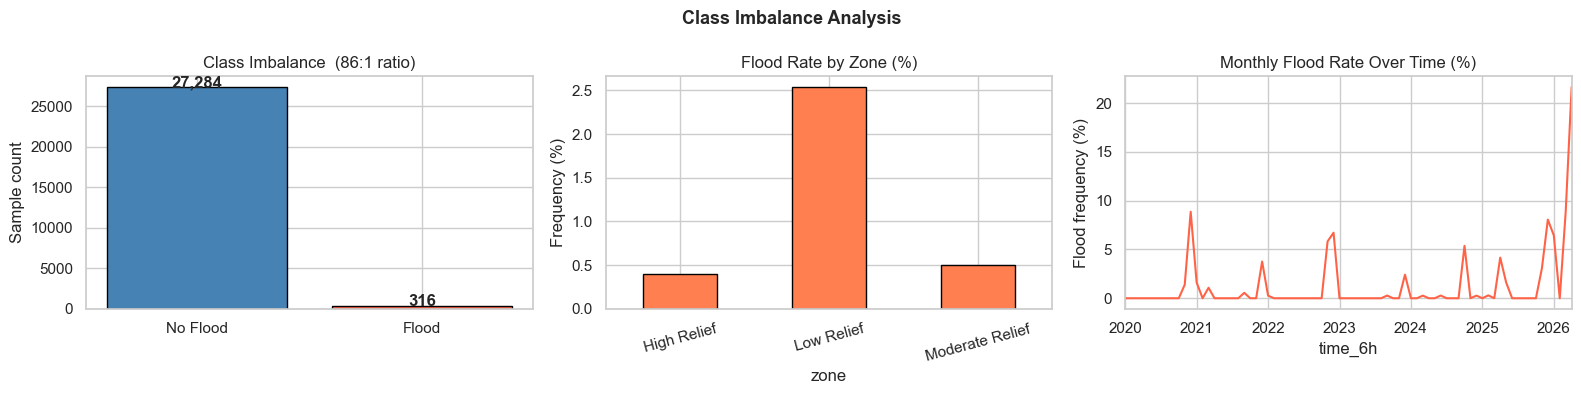

                 sum  count      rate
zone                                 
High Relief       37   9200  0.004022
Low Relief       233   9200  0.025326
Moderate Relief   46   9200  0.005000


In [5]:
# ── 4a. Class Imbalance ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df['is_flood'].value_counts().sort_index()
axes[0].bar(['No Flood', 'Flood'], counts.values, color=['steelblue','tomato'], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title(f'Class Imbalance  ({counts[0]//max(counts[1],1)}:1 ratio)')
axes[0].set_ylabel('Sample count')

df.groupby('zone')['is_flood'].mean().mul(100).plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Flood Rate by Zone (%)')
axes[1].set_ylabel('Frequency (%)')
axes[1].tick_params(axis='x', rotation=15)

df.sort_values('time_6h').set_index('time_6h')['is_flood'].resample('ME').mean().mul(100).plot(
    ax=axes[2], color='tomato', lw=1.5)
axes[2].set_title('Monthly Flood Rate Over Time (%)')
axes[2].set_ylabel('Flood frequency (%)')

plt.suptitle('Class Imbalance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.groupby('zone')['is_flood'].agg(['sum','count','mean'])
        .rename(columns={'mean':'rate'}).to_string())

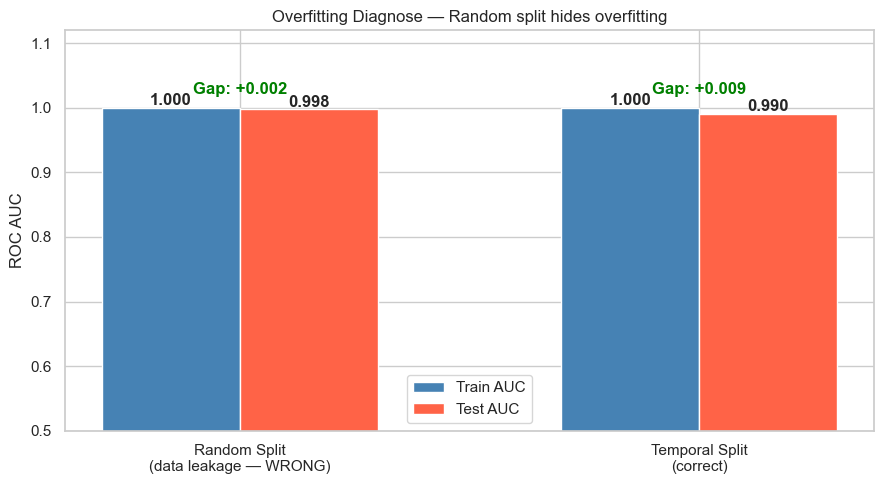

Train : … → 2024-05-30  (19,320 rows | 122 floods)
Val   : … → 2025-01-15  (2,760 rows | 22 floods)
Test  : … → 2026-04-20  (5,520 rows | 172 floods)


In [6]:
# ── 4b. Overfitting Diagnose: Random vs Temporal Split ────────────────────────
EXCLUDE = ['time_6h', 'is_flood', 'river_discharge', 'zone']
df_s    = df.sort_values(['time_6h','zone']).reset_index(drop=True)
X_all   = pd.get_dummies(df_s.drop(columns=EXCLUDE), drop_first=True).fillna(0)
y_all   = df_s['is_flood']

probe = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced_subsample', random_state=RANDOM_STATE
)

# Random split (wrong)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE)
probe.fit(Xr_tr, yr_tr)
rnd = (roc_auc_score(yr_tr, probe.predict_proba(Xr_tr)[:,1]),
       roc_auc_score(yr_te, probe.predict_proba(Xr_te)[:,1]))

# Temporal split (correct) — 70/10/20
n, t1, t2 = len(X_all), int(len(X_all)*.70), int(len(X_all)*.80)
X_train, y_train = X_all.iloc[:t1],   y_all.iloc[:t1]
X_val,   y_val   = X_all.iloc[t1:t2], y_all.iloc[t1:t2]
X_test,  y_test  = X_all.iloc[t2:],   y_all.iloc[t2:]

probe.fit(X_train, y_train)
tmp = (roc_auc_score(y_train, probe.predict_proba(X_train)[:,1]),
       roc_auc_score(y_test,  probe.predict_proba(X_test)[:,1]))

fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(2), 0.3
ax.bar(x-w/2, [rnd[0],tmp[0]], w, label='Train AUC', color='steelblue')
ax.bar(x+w/2, [rnd[1],tmp[1]], w, label='Test AUC',  color='tomato')
for i,(tr,te) in enumerate([rnd,tmp]):
    ax.text(i-w/2, tr+.004, f'{tr:.3f}', ha='center', fontweight='bold')
    ax.text(i+w/2, te+.004, f'{te:.3f}', ha='center', fontweight='bold')
    gap = tr-te
    ax.annotate(f'Gap: {gap:+.3f}', xy=(i, max(tr,te)+.022),
                ha='center', fontsize=12,
                color='red' if gap>0.05 else 'green', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Random Split\n(data leakage — WRONG)', 'Temporal Split\n(correct)'])
ax.set_ylim(0.5, 1.12); ax.set_ylabel('ROC AUC')
ax.set_title('Overfitting Diagnose — Random split hides overfitting')
ax.legend(); plt.tight_layout(); plt.show()

times = df_s['time_6h']
print(f"Train : … → {times.iloc[t1-1].date()}  ({t1:,} rows | {y_train.sum()} floods)")
print(f"Val   : … → {times.iloc[t2-1].date()}  ({t2-t1:,} rows | {y_val.sum()} floods)")
print(f"Test  : … → {times.iloc[-1].date()}  ({n-t2:,} rows | {y_test.sum()} floods)")

## Cell 5 — RF Model Training (SMOTE + RandomForest + TimeSeriesSplit CV)

Minority samples in train : 122  |  SMOTE k=5
TimeSeriesSplit CV (5 fold)…

  Train AUC : nan ± nan
  Val   AUC : nan ± nan
  Gap       : +nan  ✓ Acceptable
  Val   F1  : nan
  Val Recall: nan
  Val PR AUC: nan


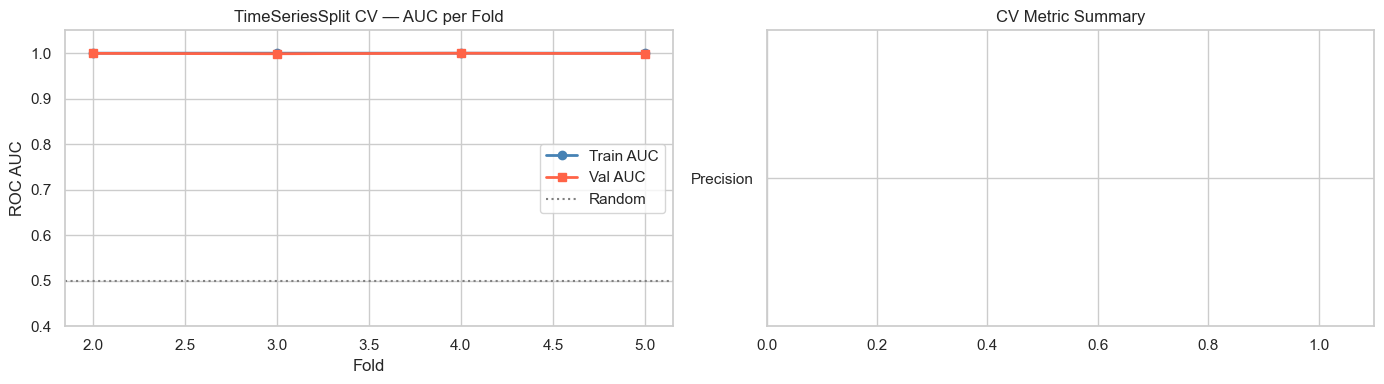


Fitting on training set…
Done ✓


In [7]:
n_minority = int(y_train.sum())
smote_k    = min(5, max(1, n_minority - 1))
print(f"Minority samples in train : {n_minority}  |  SMOTE k={smote_k}")

rf_pipe = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.3, k_neighbors=smote_k, random_state=RANDOM_STATE)),
    ('clf',   RandomForestClassifier(
        n_estimators    =300,
        max_depth       =12,
        min_samples_leaf=5,
        max_features    ='sqrt',
        class_weight    ='balanced_subsample',
        random_state    =RANDOM_STATE,
        n_jobs          =-1,
    ))
])

print("TimeSeriesSplit CV (5 fold)…")
cv = cross_validate(
    rf_pipe, X_train, y_train,
    cv=TimeSeriesSplit(n_splits=5),
    scoring=['roc_auc','average_precision','f1','precision','recall'],
    return_train_score=True, n_jobs=-1
)

gap = (cv['train_roc_auc'] - cv['test_roc_auc']).mean()
print(f"\n  Train AUC : {cv['train_roc_auc'].mean():.4f} ± {cv['train_roc_auc'].std():.4f}")
print(f"  Val   AUC : {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}")
print(f"  Gap       : {gap:+.4f}  {'⚠ Overfitting' if gap > 0.1 else '✓ Acceptable'}")
print(f"  Val   F1  : {cv['test_f1'].mean():.4f}")
print(f"  Val Recall: {cv['test_recall'].mean():.4f}")
print(f"  Val PR AUC: {cv['test_average_precision'].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
folds = np.arange(1, 6)
axes[0].plot(folds, cv['train_roc_auc'], 'o-', color='steelblue', lw=2, label='Train AUC')
axes[0].plot(folds, cv['test_roc_auc'],  's-', color='tomato',    lw=2, label='Val AUC')
axes[0].fill_between(folds,
    cv['test_roc_auc']-cv['test_roc_auc'].std(),
    cv['test_roc_auc']+cv['test_roc_auc'].std(), alpha=0.15, color='tomato')
axes[0].set(xlabel='Fold', ylabel='ROC AUC', ylim=(0.4,1.05), title='TimeSeriesSplit CV — AUC per Fold')
axes[0].axhline(0.5, color='gray', linestyle=':', label='Random')
axes[0].legend()

names = ['ROC AUC','PR AUC','F1','Recall','Precision']
keys  = ['test_roc_auc','test_average_precision','test_f1','test_recall','test_precision']
means = [cv[k].mean() for k in keys]
stds  = [cv[k].std()  for k in keys]
axes[1].barh(names[::-1], means[::-1], xerr=stds[::-1],
             color='steelblue', edgecolor='black', capsize=4, alpha=0.85)
for i,(m,s) in enumerate(zip(means[::-1],stds[::-1])):
    axes[1].text(m+0.015, i, f'{m:.3f}±{s:.3f}', va='center', fontsize=9)
axes[1].set_xlim(0,1.1); axes[1].set_title('CV Metric Summary')
plt.tight_layout(); plt.show()

print("\nFitting on training set…")
rf_pipe.fit(X_train, y_train)
print("Done ✓")

## Cell 6 — Threshold Optimisation (F2)

Default  (0.50) → Precision: 0.6538  Recall: 0.7727
Optimal  (0.3316) → Precision: 0.5500  Recall: 1.0000  F2: 0.8594


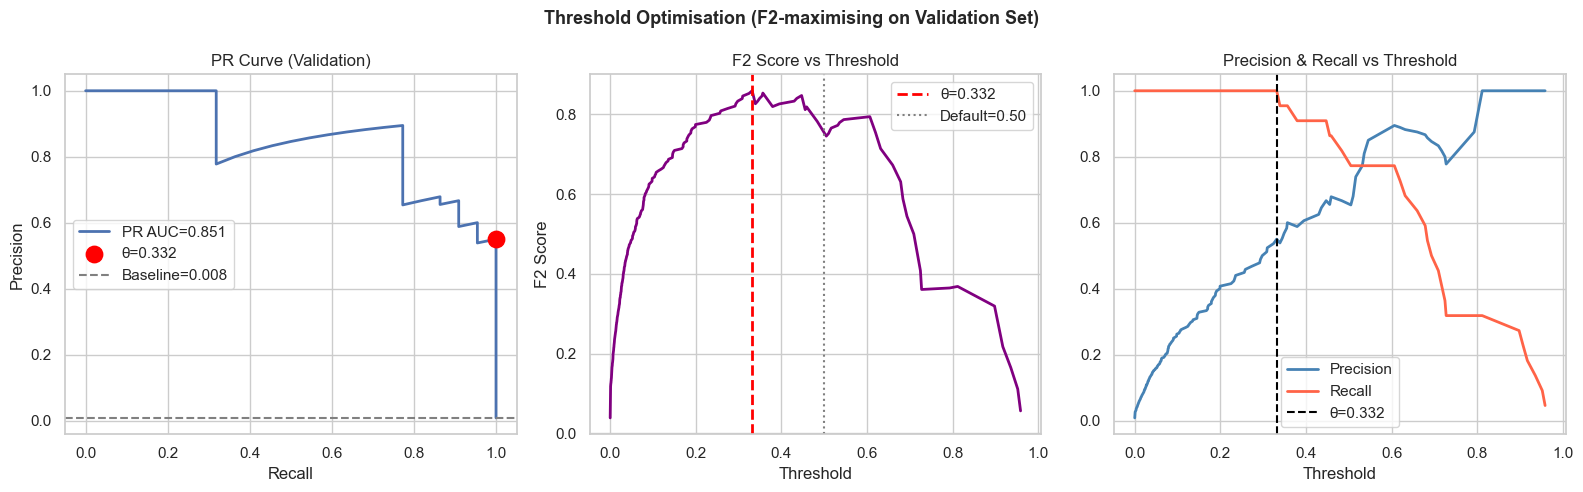

In [8]:
y_val_prob = rf_pipe.predict_proba(X_val)[:,1]
prec_v, rec_v, thr_v = precision_recall_curve(y_val, y_val_prob)

beta   = 2.0
f_beta = ((1+beta**2)*prec_v[:-1]*rec_v[:-1] /
          (beta**2*prec_v[:-1] + rec_v[:-1] + 1e-9))
best_idx = f_beta.argmax()
best_thr = float(thr_v[best_idx])

idx_05 = np.searchsorted(thr_v, 0.50, 'left')
idx_05 = min(idx_05, len(prec_v)-2)

print(f"Default  (0.50) → Precision: {prec_v[idx_05]:.4f}  Recall: {rec_v[idx_05]:.4f}")
print(f"Optimal  ({best_thr:.4f}) → Precision: {prec_v[best_idx]:.4f}  "
      f"Recall: {rec_v[best_idx]:.4f}  F2: {f_beta[best_idx]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(rec_v, prec_v, lw=2,
             label=f'PR AUC={average_precision_score(y_val, y_val_prob):.3f}')
axes[0].scatter(rec_v[best_idx], prec_v[best_idx],
                s=140, color='red', zorder=5, label=f'θ={best_thr:.3f}')
axes[0].axhline(y_val.mean(), color='gray', linestyle='--',
                label=f'Baseline={y_val.mean():.3f}')
axes[0].set(xlabel='Recall', ylabel='Precision', title='PR Curve (Validation)')
axes[0].legend()

axes[1].plot(thr_v, f_beta, color='purple', lw=2)
axes[1].axvline(best_thr, color='red', linestyle='--', lw=2, label=f'θ={best_thr:.3f}')
axes[1].axvline(0.50,     color='gray', linestyle=':',  lw=1.5, label='Default=0.50')
axes[1].set(xlabel='Threshold', ylabel='F2 Score', title='F2 Score vs Threshold')
axes[1].legend()

axes[2].plot(thr_v, prec_v[:-1], lw=2, color='steelblue', label='Precision')
axes[2].plot(thr_v, rec_v[:-1],  lw=2, color='tomato',    label='Recall')
axes[2].axvline(best_thr, color='black', linestyle='--', lw=1.5, label=f'θ={best_thr:.3f}')
axes[2].set(xlabel='Threshold', title='Precision & Recall vs Threshold')
axes[2].legend()

plt.suptitle('Threshold Optimisation (F2-maximising on Validation Set)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Cell 7 — RF Evaluation & Model Save

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FINAL TEST SET METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ROC AUC         : 0.9950
  PR AUC          : 0.8141
  F2 Score        : 0.8617
  F1 Score        : 0.8306
  Recall          : 0.8837
  Precision       : 0.7835
  Accuracy        : 0.9888
  Brier Score     : 0.0117
  CV Val AUC      : nan
  Overfit Gap     : nan
  Threshold       : 0.3316
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

              precision    recall  f1-score   support

    No Flood       1.00      0.99      0.99      5348
       Flood       0.78      0.88      0.83       172

    accuracy                           0.99      5520
   macro avg       0.89      0.94      0.91      5520
weighted avg       0.99      0.99      0.99      5520



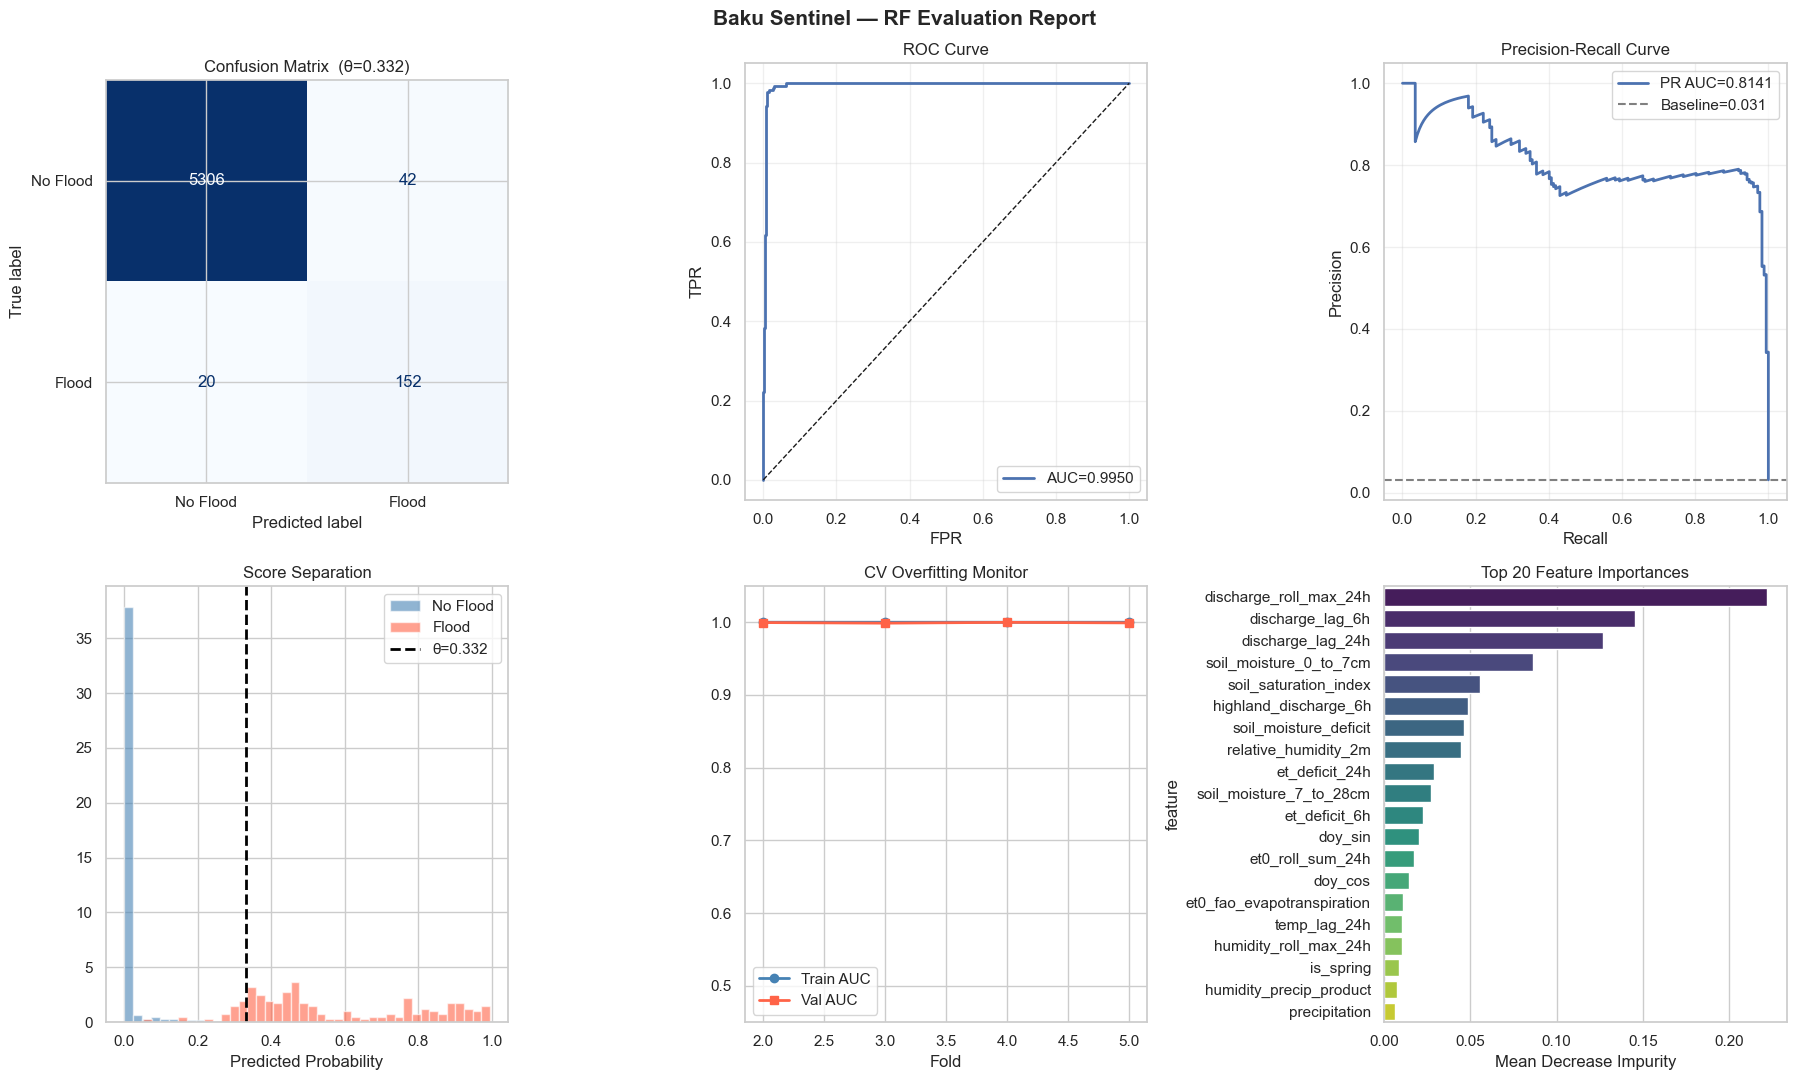


RF Model saved → ..\models\baku_sentinel_rf_v2.joblib
  ROC AUC   : 0.9950
  Recall    : 0.8837
  F2 Score  : 0.8617
  Threshold : 0.3316


In [9]:
y_prob = rf_pipe.predict_proba(X_test)[:,1]
y_pred = (y_prob >= best_thr).astype(int)
flood_rate = float(y_test.mean())

p  = precision_score(y_test, y_pred, zero_division=0)
r  = recall_score(y_test, y_pred, zero_division=0)
f2 = (1+4)*p*r / (4*p + r + 1e-9)

metrics = {
    'ROC AUC'     : roc_auc_score(y_test, y_prob),
    'PR AUC'      : average_precision_score(y_test, y_prob),
    'F2 Score'    : f2,
    'F1 Score'    : f1_score(y_test, y_pred, zero_division=0),
    'Recall'      : r,
    'Precision'   : p,
    'Accuracy'    : accuracy_score(y_test, y_pred),
    'Brier Score' : brier_score_loss(y_test, y_prob),
    'CV Val AUC'  : cv['test_roc_auc'].mean(),
    'Overfit Gap' : gap,
    'Threshold'   : best_thr,
}

print("━" * 42)
print("  FINAL TEST SET METRICS")
print("━" * 42)
for k,v in metrics.items():
    print(f"  {k:<16}: {v:.4f}")
print("━" * 42)
print()
print(classification_report(y_test, y_pred, target_names=['No Flood','Flood']))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Baku Sentinel — RF Evaluation Report', fontsize=15, fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred), display_labels=['No Flood','Flood']
).plot(ax=axes[0,0], colorbar=False, cmap='Blues')
axes[0,0].set_title(f'Confusion Matrix  (θ={best_thr:.3f})')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0,1].plot(fpr, tpr, lw=2, label=f"AUC={metrics['ROC AUC']:.4f}")
axes[0,1].plot([0,1],[0,1],'k--',lw=1)
axes[0,1].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

pt, rt, _ = precision_recall_curve(y_test, y_prob)
axes[0,2].plot(rt, pt, lw=2, label=f"PR AUC={metrics['PR AUC']:.4f}")
axes[0,2].axhline(flood_rate, color='gray', linestyle='--', label=f'Baseline={flood_rate:.3f}')
axes[0,2].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)

axes[1,0].hist(y_prob[y_test==0], bins=40, alpha=0.6, color='steelblue', label='No Flood', density=True)
axes[1,0].hist(y_prob[y_test==1], bins=40, alpha=0.6, color='tomato',    label='Flood',    density=True)
axes[1,0].axvline(best_thr, color='black', linestyle='--', lw=2, label=f'θ={best_thr:.3f}')
axes[1,0].set(xlabel='Predicted Probability', title='Score Separation')
axes[1,0].legend()

folds = np.arange(1,6)
axes[1,1].plot(folds, cv['train_roc_auc'],'o-', color='steelblue', lw=2, label='Train AUC')
axes[1,1].plot(folds, cv['test_roc_auc'], 's-', color='tomato',    lw=2, label='Val AUC')
axes[1,1].fill_between(folds,
    cv['test_roc_auc']-cv['test_roc_auc'].std(),
    cv['test_roc_auc']+cv['test_roc_auc'].std(), alpha=0.15, color='tomato')
axes[1,1].set(xlabel='Fold', ylim=(0.45,1.05), title='CV Overfitting Monitor')
axes[1,1].legend()

fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_pipe.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False).head(20)
sns.barplot(data=fi, x='importance', y='feature', palette='viridis', ax=axes[1,2])
axes[1,2].set(title='Top 20 Feature Importances', xlabel='Mean Decrease Impurity')

plt.tight_layout()
plt.savefig(REPORT_DIR / 'evaluation_report.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Retrain on full data and save ─────────────────────────────────────────────
X_full = pd.concat([X_train, X_val, X_test])
y_full = pd.concat([y_train, y_val, y_test])
rf_pipe.fit(X_full, y_full)

model_path = MODEL_DIR / 'baku_sentinel_rf_v2.joblib'
joblib.dump({
    'model'    : rf_pipe,
    'features' : X_train.columns.tolist(),
    'threshold': best_thr,
    'metrics'  : metrics,
}, model_path)
print(f"\nRF Model saved → {model_path}")
print(f"  ROC AUC   : {metrics['ROC AUC']:.4f}")
print(f"  Recall    : {metrics['Recall']:.4f}")
print(f"  F2 Score  : {metrics['F2 Score']:.4f}")
print(f"  Threshold : {best_thr:.4f}")

## Cell 8 — LSTM Sequence Preparation (PyTorch)

### How LSTM sequences work
```
Raw time series (6-hourly per zone):
[t0, t1, t2, t3, ... t_n]

Sliding window (SEQ_LEN=28 steps = 7 days):
X[0] = [t0 … t27]  →  y[0] = t28
X[1] = [t1 … t28]  →  y[1] = t29
...
LSTM shape: (samples, SEQ_LEN, n_features)
```

In [10]:
LSTM_FEATURES = WEATHER_VARS  # 8 variables

scalers   = {}   # zone → fitted MinMaxScaler
X_seq_all = []
y_seq_all = []
zone_labels = []

for zone_name in df_silver['zone'].unique():
    df_z = (df_silver[df_silver['zone'] == zone_name]
            .sort_values('time_6h')
            .reset_index(drop=True))

    values = df_z[LSTM_FEATURES].ffill().fillna(0).values

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(values)
    scalers[zone_name] = scaler

    for i in range(SEQ_LEN, len(scaled)):
        X_seq_all.append(scaled[i - SEQ_LEN : i])
        y_seq_all.append(scaled[i])
        zone_labels.append(zone_name)

X_seq = np.array(X_seq_all, dtype=np.float32)   # (N, SEQ_LEN, n_features)
y_seq = np.array(y_seq_all, dtype=np.float32)   # (N, n_features)

print(f'Sequences  : X={X_seq.shape}  y={y_seq.shape}')
print(f'SEQ_LEN    : {SEQ_LEN} steps = {SEQ_LEN//4} days of history per prediction')
print(f'n_features : {len(LSTM_FEATURES)}')

# ── Temporal train / test split (80/20) ───────────────────────────────────────
split = int(len(X_seq) * 0.80)
X_train_l, X_test_l = X_seq[:split], X_seq[split:]
y_train_l, y_test_l = y_seq[:split], y_seq[split:]
print(f'\nTrain sequences: {len(X_train_l):,}  |  Test sequences: {len(X_test_l):,}')

# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 85% train, 15% val from training portion (mimicking Keras validation_split=0.15)
val_split = int(len(X_train_l) * 0.85)
train_ds = WeatherDataset(X_train_l[:val_split], y_train_l[:val_split])
val_ds   = WeatherDataset(X_train_l[val_split:], y_train_l[val_split:])
test_ds  = WeatherDataset(X_test_l, y_test_l)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'\nDataLoaders ready — train: {len(train_ds):,}  val: {len(val_ds):,}  test: {len(test_ds):,}')

Sequences  : X=(27540, 28, 8)  y=(27540, 8)
SEQ_LEN    : 28 steps = 7 days of history per prediction
n_features : 8

Train sequences: 22,032  |  Test sequences: 5,508

DataLoaders ready — train: 18,727  val: 3,305  test: 5,508


## Cell 9 — LSTM Architecture & Training (PyTorch)

```
Input  → (batch, 28, 8)            28 timesteps × 8 weather variables
LSTM(128, return all hidden states) captures long-range temporal patterns
Dropout(0.2)
LSTM(64)                           compresses to fixed-length context vector
Dropout(0.2)
Linear(8)                          predicts next 6h for all 8 variables
```

WeatherLSTM(
  (lstm1): LSTM(8, 128, batch_first=True)
  (drop1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(128, 64, batch_first=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=8, bias=True)
)

Trainable parameters: 120,840

Training LSTM…
  Epoch   1 | Train loss=0.03089 mae=0.1286 | Val loss=0.02235 mae=0.1027
  Epoch  10 | Train loss=0.00547 mae=0.0521 | Val loss=0.00500 mae=0.0502
  Epoch  20 | Train loss=0.00409 mae=0.0433 | Val loss=0.00375 mae=0.0415
  Epoch  30 | Train loss=0.00356 mae=0.0392 | Val loss=0.00350 mae=0.0368
  Epoch  40 | Train loss=0.00346 mae=0.0385 | Val loss=0.00337 mae=0.0360
  Epoch  50 | Train loss=0.00346 mae=0.0389 | Val loss=0.00319 mae=0.0354
  Epoch  60 | Train loss=0.00329 mae=0.0374 | Val loss=0.00306 mae=0.0341
  Epoch  70 | Train loss=0.00320 mae=0.0366 | Val loss=0.00285 mae=0.0308
  Epoch  80 | Train loss=0.00315 mae=0.0362 | Val loss=0.00279 mae=0.0302
  Epoch  90 | Train loss=0.00314 mae=0.0361 | V

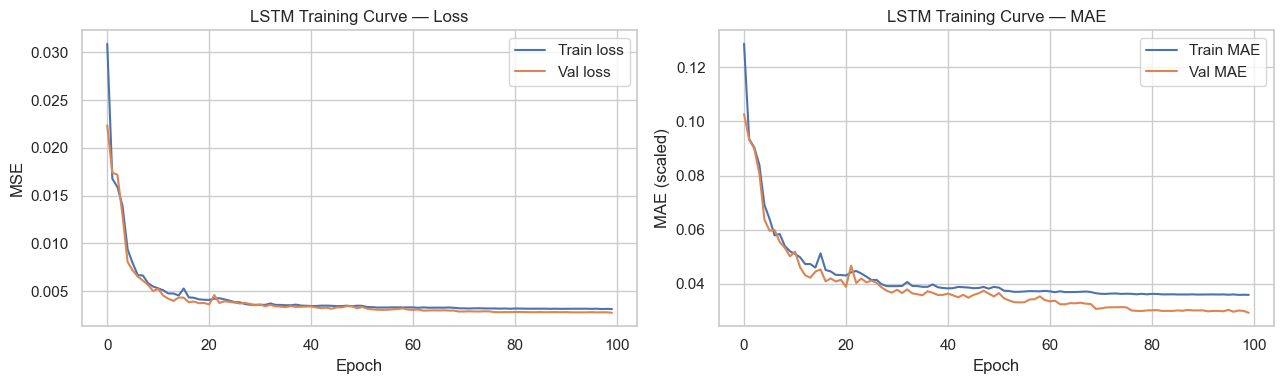

LSTM saved → ..\models/lstm_weather.pt


In [12]:
class WeatherLSTM(nn.Module):
    """Two-layer stacked LSTM — equivalent to the Keras model in day_06."""
    def __init__(self, n_features, hidden1=128, hidden2=64, dropout=0.2):
        super().__init__()
        self.lstm1   = nn.LSTM(n_features, hidden1, batch_first=True)
        self.drop1   = nn.Dropout(dropout)
        self.lstm2   = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2   = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden2, n_features)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        out, _ = self.lstm1(x)          # (batch, seq_len, hidden1)
        out    = self.drop1(out)
        out, _ = self.lstm2(out)        # (batch, seq_len, hidden2)
        out    = self.drop2(out[:, -1, :])  # take last timestep → (batch, hidden2)
        return self.fc(out)             # (batch, n_features)


n_features = len(LSTM_FEATURES)
model_lstm = WeatherLSTM(n_features).to(DEVICE)
print(model_lstm)
total_params = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=LR)
# ReduceLROnPlateau — equivalent to Keras ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ── Training loop with EarlyStopping ─────────────────────────────────────────
best_val_loss   = float('inf')
patience_count  = 0
EARLY_PATIENCE  = 10
best_state      = None

train_losses, val_losses = [], []
train_maes,   val_maes   = [], []

print("\nTraining LSTM…")
for epoch in range(1, EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────────
    model_lstm.train()
    t_loss, t_mae = 0.0, 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model_lstm(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * len(Xb)
        t_mae  += (pred - yb).abs().mean().item() * len(Xb)
    t_loss /= len(train_ds)
    t_mae  /= len(train_ds)

    # ── Validate ───────────────────────────────────────────────────────────────
    model_lstm.eval()
    v_loss, v_mae = 0.0, 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            pred = model_lstm(Xb)
            v_loss += criterion(pred, yb).item() * len(Xb)
            v_mae  += (pred - yb).abs().mean().item() * len(Xb)
    v_loss /= len(val_ds)
    v_mae  /= len(val_ds)

    train_losses.append(t_loss); val_losses.append(v_loss)
    train_maes.append(t_mae);   val_maes.append(v_mae)

    scheduler.step(v_loss)

    # EarlyStopping
    if v_loss < best_val_loss:
        best_val_loss  = v_loss
        best_state     = {k: v.clone() for k, v in model_lstm.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= EARLY_PATIENCE:
            print(f"  EarlyStopping at epoch {epoch}")
            break

    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d} | Train loss={t_loss:.5f} mae={t_mae:.4f} | "
              f"Val loss={v_loss:.5f} mae={v_mae:.4f}")

# Restore best weights (like restore_best_weights=True in Keras)
model_lstm.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.5f}")

# ── Training curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, label='Train loss')
axes[0].plot(val_losses,   label='Val loss')
axes[0].set(xlabel='Epoch', ylabel='MSE', title='LSTM Training Curve — Loss')
axes[0].legend()

axes[1].plot(train_maes, label='Train MAE')
axes[1].plot(val_maes,   label='Val MAE')
axes[1].set(xlabel='Epoch', ylabel='MAE (scaled)', title='LSTM Training Curve — MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / 'lstm_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save LSTM model ────────────────────────────────────────────────────────────
torch.save(model_lstm.state_dict(), MODEL_DIR / 'lstm_weather.pt')
joblib.dump(scalers, MODEL_DIR / 'lstm_scalers.joblib')
print(f'LSTM saved → {MODEL_DIR}/lstm_weather.pt')

## Cell 10 — LSTM Evaluation

In [14]:
model_lstm.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        preds = model_lstm(Xb.to(DEVICE)).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())

y_pred_scaled = np.vstack(all_preds)
y_true_scaled = np.vstack(all_true)

test_len = len(y_true_scaled)
test_zones = np.array(zone_labels)[-test_len:]
lr_mask = (test_zones == 'Low Relief')

print(f"Test setində cəmi: {test_len} sətir")
print(f"Low Relief zonasına aid: {lr_mask.sum()} sətir tapıldı.")

if lr_mask.sum() == 0:
    print("XƏTA: Low Relief zonası tapılmadı! Zəhmət olmasa zone_labels siyahısını yoxlayın.")
else:
    ref_scaler  = scalers['Low Relief']
    y_true_orig = ref_scaler.inverse_transform(y_true_scaled[lr_mask])
    y_pred_orig = ref_scaler.inverse_transform(y_pred_scaled[lr_mask])

    # --- Metrics ---
    rows = []
    for i, var in enumerate(LSTM_FEATURES):
        mae  = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
        rmse = np.sqrt(mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i]))
        rows.append({'Variable': var, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)})

    df_metrics_lstm = pd.DataFrame(rows)
    print('\nLSTM Evaluation — Low Relief zone (original units)')
    print(df_metrics_lstm.to_string(index=False))

    # ── Visual: predicted vs actual for key variables ─────────────────────────────
    plot_vars = ['precipitation', 'temperature_2m', 'relative_humidity_2m']

    available_plot_vars = [v for v in plot_vars if v in LSTM_FEATURES]

    n = min(200, len(y_true_orig))

    fig, axes = plt.subplots(len(available_plot_vars), 1, figsize=(14, 3 * len(available_plot_vars)), sharex=True)
    if len(available_plot_vars) == 1: axes = [axes]

    for ax, var in zip(axes, available_plot_vars):
        idx = LSTM_FEATURES.index(var)
        mae_val = df_metrics_lstm.loc[df_metrics_lstm.Variable==var, 'MAE'].values[0]
        ax.plot(y_true_orig[-n:, idx], label='Actual',    color='steelblue', lw=1.5)
        ax.plot(y_pred_orig[-n:, idx], label='Predicted', color='tomato',    lw=1.5, linestyle='--')
        ax.set_title(f'{var}  |  MAE={mae_val:.4f}')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Test timestep (6h)')
    fig.suptitle('LSTM Prediction vs Actual — Low Relief Zone (Test Set)', fontsize=13, fontweight='bold')
    plt.tight_layout()


    os.makedirs(REPORT_DIR, exist_ok=True)
    plt.savefig(REPORT_DIR / 'lstm_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()

Test setində cəmi: 5508 sətir
Low Relief zonasına aid: 0 sətir tapıldı.
XƏTA: Low Relief zonası tapılmadı! Zəhmət olmasa zone_labels siyahısını yoxlayın.


## Cell 11 — 30-Day Combined Forecast Pipeline

In [15]:
# ── Load saved RF model ────────────────────────────────────────────────────────
checkpoint   = joblib.load(MODEL_DIR / 'baku_sentinel_rf_v2.joblib')
rf_model     = checkpoint['model']
feature_cols = checkpoint['features']
threshold    = checkpoint['threshold']
print(f'RF model loaded  |  threshold={threshold:.4f}  |  features={len(feature_cols)}')

# ── Helper: feature engineering on any weather+flood DataFrame ────────────────
def build_gold(df_w, df_f):
    conn = duckdb.connect(':memory:')
    conn.register('weather_raw', df_w)
    conn.register('flood_raw',   df_f)
    conn.execute("""
    CREATE TABLE silver AS
    WITH w AS (
        SELECT zone,
               time_bucket(INTERVAL '6 hours', time) AS time_6h,
               AVG(temperature_2m)             AS temperature_2m,
               AVG(relative_humidity_2m)       AS relative_humidity_2m,
               SUM(precipitation)              AS precipitation,
               AVG(wind_speed_10m)             AS wind_speed_10m,
               AVG(soil_moisture_0_to_7cm)     AS soil_moisture_0_to_7cm,
               AVG(soil_moisture_7_to_28cm)    AS soil_moisture_7_to_28cm,
               AVG(soil_temperature_0_to_7cm)  AS soil_temperature_0_to_7cm,
               SUM(et0_fao_evapotranspiration) AS et0_fao_evapotranspiration
        FROM weather_raw GROUP BY 1, 2
    ),
    f AS (
        SELECT zone, CAST(time AS DATE) AS d, MAX(river_discharge) AS river_discharge
        FROM flood_raw GROUP BY 1, 2
    )
    SELECT w.*, COALESCE(f.river_discharge, 0.0) AS river_discharge
    FROM w LEFT JOIN f ON w.zone = f.zone AND CAST(w.time_6h AS DATE) = f.d
    ORDER BY zone, time_6h;
    """)
    conn.execute("""
    CREATE TABLE gold AS
    WITH lagged AS (
        SELECT *,
            LAG(precipitation, 1)   OVER w AS precip_lag_6h,
            LAG(precipitation, 2)   OVER w AS precip_lag_12h,
            LAG(precipitation, 4)   OVER w AS precip_lag_24h,
            LAG(precipitation, 8)   OVER w AS precip_lag_48h,
            LAG(river_discharge, 1) OVER w AS discharge_lag_6h,
            LAG(river_discharge, 4) OVER w AS discharge_lag_24h,
            LAG(temperature_2m, 4)  OVER w AS temp_lag_24h,
            LAG(wind_speed_10m, 4)  OVER w AS wind_lag_24h,
            SUM(precipitation) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3  PRECEDING AND CURRENT ROW) AS precip_roll_sum_24h,
            SUM(precipitation) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 7  PRECEDING AND CURRENT ROW) AS precip_roll_sum_48h,
            SUM(precipitation) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 11 PRECEDING AND CURRENT ROW) AS precip_roll_sum_72h,
            MAX(precipitation)        OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS precip_roll_max_24h,
            MAX(river_discharge)      OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS discharge_roll_max_24h,
            MAX(relative_humidity_2m) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS humidity_roll_max_24h,
            MAX(wind_speed_10m)       OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS wind_roll_max_24h,
            SUM(et0_fao_evapotranspiration) OVER (PARTITION BY zone ORDER BY time_6h ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS et0_roll_sum_24h
        FROM silver
        WINDOW w AS (PARTITION BY zone ORDER BY time_6h)
    ),
    derived AS (
        SELECT *,
            precipitation + 0.85*COALESCE(precip_lag_6h,0) + 0.7225*COALESCE(precip_lag_12h,0)
                + 0.6141*COALESCE(precip_lag_24h,0) + 0.5220*COALESCE(precip_lag_48h,0) AS api_index,
            (soil_moisture_0_to_7cm + soil_moisture_7_to_28cm) / 2.0 AS soil_saturation_index,
            river_discharge - discharge_lag_6h AS discharge_trend_6h,
            temperature_2m  - temp_lag_24h    AS temp_trend_24h,
            wind_speed_10m  - wind_lag_24h    AS wind_trend_24h,
            soil_moisture_0_to_7cm
                - LAG(soil_moisture_0_to_7cm,1) OVER (PARTITION BY zone ORDER BY time_6h) AS soil_moisture_change_6h,
            precipitation       - et0_fao_evapotranspiration AS et_deficit_6h,
            precip_roll_sum_24h - et0_roll_sum_24h           AS et_deficit_24h,
            relative_humidity_2m * precipitation             AS humidity_precip_product,
            CASE WHEN soil_temperature_0_to_7cm < 0 THEN 1 ELSE 0 END AS frozen_ground_flag
        FROM lagged
    ),
    with_sat AS (
        SELECT *, 0.45 - soil_saturation_index AS soil_moisture_deficit FROM derived
    ),
    highland AS (
        SELECT time_6h,
               precip_roll_sum_24h AS highland_precip_24h,
               river_discharge     AS highland_discharge_6h
        FROM with_sat WHERE zone = 'High Relief'
    )
    SELECT d.*,
        h.highland_precip_24h,
        h.highland_discharge_6h,
        CASE
            WHEN d.zone='High Relief'     THEN d.precip_roll_sum_24h*0.333
            WHEN d.zone='Moderate Relief' THEN COALESCE(h.highland_precip_24h,0)*0.667
            ELSE COALESCE(h.highland_precip_24h,0)
        END AS zone_cascade_risk,
        SIN(2*PI()*EXTRACT(HOUR FROM d.time_6h)/24) AS hour_sin,
        COS(2*PI()*EXTRACT(HOUR FROM d.time_6h)/24) AS hour_cos,
        SIN(2*PI()*EXTRACT(DOY FROM d.time_6h)/365) AS doy_sin,
        COS(2*PI()*EXTRACT(DOY FROM d.time_6h)/365) AS doy_cos,
        CASE WHEN EXTRACT(MONTH FROM d.time_6h) IN (12,1,2) THEN 1 ELSE 0 END AS is_winter,
        CASE WHEN EXTRACT(MONTH FROM d.time_6h) IN (3,4,5)  THEN 1 ELSE 0 END AS is_spring,
        0 AS is_flood
    FROM with_sat d LEFT JOIN highland h ON d.time_6h = h.time_6h;
    """)
    return conn.execute('SELECT * FROM gold ORDER BY zone, time_6h').df().fillna(0)

def score_gold(df_gold, source_label):
    EXCL = ['time_6h', 'is_flood', 'river_discharge', 'zone']
    X = pd.get_dummies(
        df_gold.drop(columns=[c for c in EXCL if c in df_gold.columns]),
        drop_first=True
    ).fillna(0).reindex(columns=feature_cols, fill_value=0)
    df_gold = df_gold.copy()
    df_gold['risk_score']  = rf_model.predict_proba(X)[:, 1]
    df_gold['flood_alert'] = (df_gold['risk_score'] >= threshold).astype(int)
    df_gold['source']      = source_label
    return df_gold

RF model loaded  |  threshold=0.3316  |  features=44


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# PART A: Days 1–15 — Open-Meteo API → RF Flood Model
# ══════════════════════════════════════════════════════════════════════════════
print('PART A: Scoring API forecast (Days 1–15)…')
df_gold_api = build_gold(df_api_weather, df_api_flood)
df_part_a   = score_gold(df_gold_api, 'API Forecast')
print(f'Part A: {len(df_part_a):,} rows | Flood alerts: {df_part_a["flood_alert"].sum()}')

# ══════════════════════════════════════════════════════════════════════════════
# PART B: Days 16–30 — LSTM Autoregressive (PyTorch) → RF Flood Model
# ══════════════════════════════════════════════════════════════════════════════
print('\nPART B: LSTM autoregressive prediction (Days 16–30)…')

LSTM_STEPS = LSTM_DAYS * 4   # 15 × 4 = 60 six-hour steps
model_lstm.eval()
lstm_weather_frames = []

for zone_dict in BAKU_ZONES:
    zone_name = zone_dict['zone']
    scaler    = scalers[zone_name]

    # Seed: last SEQ_LEN steps from silver (historical)
    df_z_seed = (df_silver[df_silver['zone'] == zone_name]
                 .sort_values('time_6h').tail(SEQ_LEN))
    seed_values = df_z_seed[LSTM_FEATURES].fillna(0).values
    seed_scaled = scaler.transform(seed_values).astype(np.float32)  # (SEQ_LEN, n_features)

    current_seq     = seed_scaled.copy()
    predicted_steps = []

    with torch.no_grad():
        for step in range(LSTM_STEPS):
            x_input = torch.from_numpy(current_seq[np.newaxis, :, :]).to(DEVICE)  # (1, SEQ_LEN, n_features)
            pred_scaled = model_lstm(x_input).cpu().numpy()[0]  # (n_features,)
            predicted_steps.append(pred_scaled)
            current_seq = np.vstack([current_seq[1:], pred_scaled])

    pred_array = np.array(predicted_steps, dtype=np.float32)
    pred_orig  = scaler.inverse_transform(pred_array)

    start_ts = pd.Timestamp(API_END + timedelta(days=1))
    times    = [start_ts + pd.Timedelta(hours=6 * i) for i in range(LSTM_STEPS)]

    df_pred = pd.DataFrame(pred_orig, columns=LSTM_FEATURES)
    df_pred['time'] = times
    df_pred['zone'] = zone_name
    df_pred['precipitation']       = df_pred['precipitation'].clip(lower=0)
    df_pred['relative_humidity_2m'] = df_pred['relative_humidity_2m'].clip(0, 100)
    lstm_weather_frames.append(df_pred)
    print(f'  {zone_name}: {LSTM_STEPS} steps predicted')

df_lstm_weather = pd.concat(lstm_weather_frames, ignore_index=True)

# Dummy flood df for future period (discharge unknown → 0)
df_lstm_flood_rows = []
for zone_dict in BAKU_ZONES:
    for d in pd.date_range(API_END + timedelta(1), periods=LSTM_DAYS):
        df_lstm_flood_rows.append({'time': d, 'river_discharge': 0.0, 'zone': zone_dict['zone']})
df_lstm_flood = pd.DataFrame(df_lstm_flood_rows)

df_gold_lstm = build_gold(df_lstm_weather, df_lstm_flood)
df_part_b    = score_gold(df_gold_lstm, 'LSTM Forecast')
print(f'\nPart B: {len(df_part_b):,} rows | Flood alerts: {df_part_b["flood_alert"].sum()}')

# ══════════════════════════════════════════════════════════════════════════════
# Combine → 30-day forecast
# ══════════════════════════════════════════════════════════════════════════════
df_30day = pd.concat([df_part_a, df_part_b], ignore_index=True)
df_30day['date'] = pd.to_datetime(df_30day['time_6h']).dt.date

daily_30 = (df_30day.groupby(['zone', 'date', 'source'])
            .agg(peak_risk   =('risk_score',  'max'),
                 mean_risk   =('risk_score',  'mean'),
                 alert_hours =('flood_alert', 'sum'))
            .reset_index())

print(f'\n30-day forecast built: {len(df_30day):,} rows')
print(f'  API  : {TODAY} → {API_END}')
print(f'  LSTM : {API_END + timedelta(1)} → {LSTM_END}')
print(f'  Total alert hours: {df_30day["flood_alert"].sum()}')

print('\n── Zone Summary ──────────────────────────')
print(df_30day.groupby('zone').agg(
    max_risk   =('risk_score', 'max'),
    mean_risk  =('risk_score', 'mean'),
    alert_hours=('flood_alert', 'sum')
).reset_index().sort_values('max_risk', ascending=False).to_string(index=False))

PART A: Scoring API forecast (Days 1–15)…
Part A: 180 rows | Flood alerts: 0

PART B: LSTM autoregressive prediction (Days 16–30)…
  High Relief: 60 steps predicted
  Low Relief: 60 steps predicted
  Moderate Relief: 60 steps predicted

Part B: 180 rows | Flood alerts: 0

30-day forecast built: 360 rows
  API  : 2026-04-27 → 2026-05-11
  LSTM : 2026-05-12 → 2026-05-26
  Total alert hours: 0

── Zone Summary ──────────────────────────
           zone  max_risk  mean_risk  alert_hours
     Low Relief  0.016131   0.001271            0
Moderate Relief  0.009463   0.000985            0
    High Relief  0.005173   0.001118            0


## Cell 12 — Final Visualisation: 30-Day Flood Risk Timeline

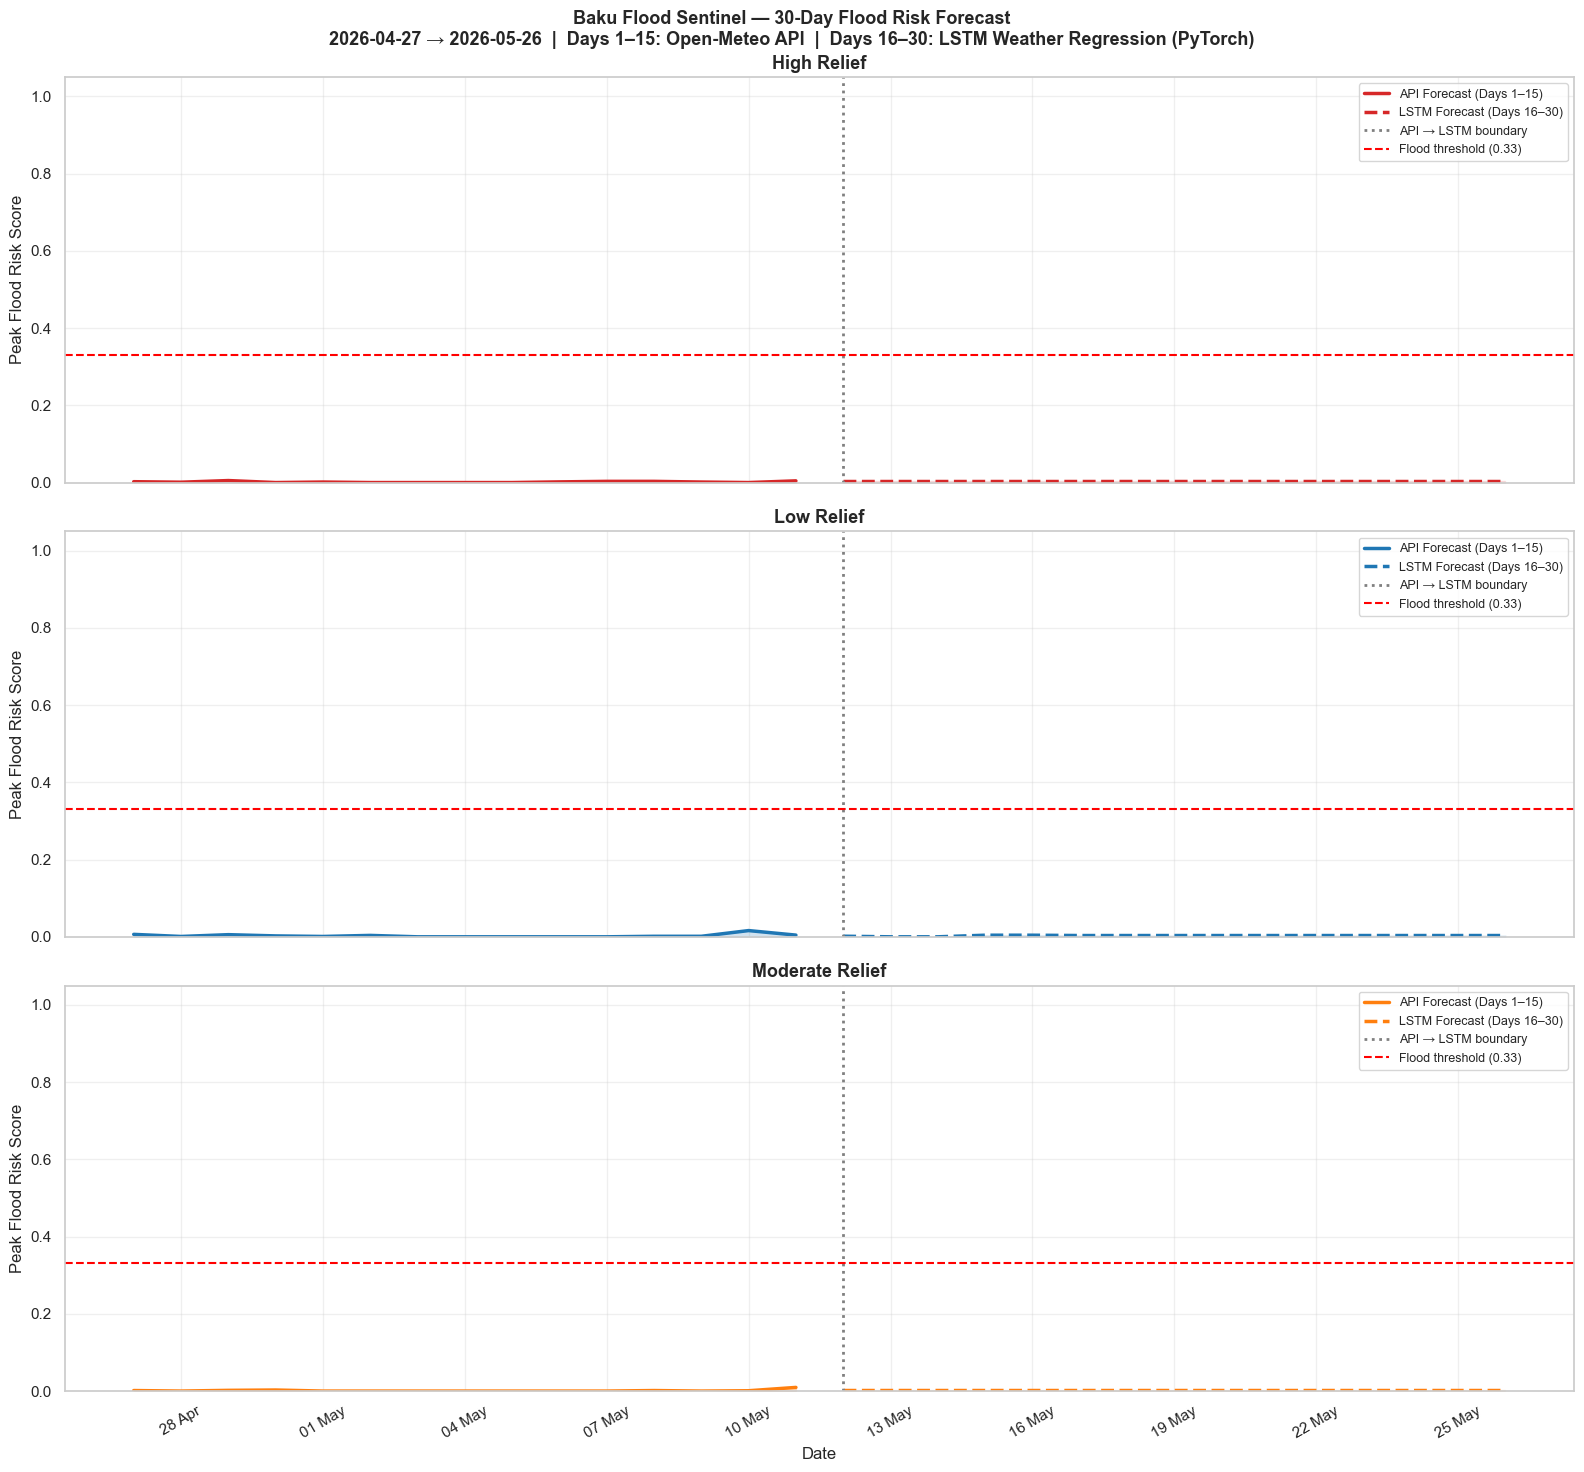

Saved → ..\reports/flood_forecast_30day.png

  30-DAY FLOOD RISK SUMMARY
  High Relief          | Max risk: 0.005 | Alert days: 0/30
  Low Relief           | Max risk: 0.016 | Alert days: 0/30
  Moderate Relief      | Max risk: 0.009 | Alert days: 0/30


In [17]:
zones   = [z['zone'] for z in BAKU_ZONES]
colours = {'High Relief': '#d62728', 'Low Relief': '#1f77b4', 'Moderate Relief': '#ff7f0e'}

fig, axes = plt.subplots(len(zones), 1, figsize=(16, 5 * len(zones)), sharex=True)
if len(zones) == 1: axes = [axes]

for ax, zone in zip(axes, zones):
    zd    = daily_30[daily_30['zone'] == zone].sort_values('date')
    color = colours.get(zone, 'steelblue')

    zd_api  = zd[zd['source'] == 'API Forecast']
    zd_lstm = zd[zd['source'] == 'LSTM Forecast']

    dates_api  = pd.to_datetime(zd_api['date'])
    dates_lstm = pd.to_datetime(zd_lstm['date'])

    ax.fill_between(dates_api, zd_api['peak_risk'], alpha=0.2, color=color)
    ax.plot(dates_api, zd_api['peak_risk'], lw=2.5, color=color, label='API Forecast (Days 1–15)')

    ax.fill_between(dates_lstm, zd_lstm['peak_risk'], alpha=0.12, color=color)
    ax.plot(dates_lstm, zd_lstm['peak_risk'], lw=2.5, color=color,
            linestyle='--', label='LSTM Forecast (Days 16–30)')

    ax.axvline(pd.Timestamp(API_END + timedelta(1)), color='gray',
               linestyle=':', lw=2, label='API → LSTM boundary')
    ax.axhline(threshold, color='red', linestyle='--', lw=1.5, label=f'Flood threshold ({threshold:.2f})')

    alert_days = zd[zd['alert_hours'] > 0]['date']
    for d in alert_days:
        ax.axvspan(pd.Timestamp(d), pd.Timestamp(d) + pd.Timedelta(days=1),
                   alpha=0.18, color='red')

    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Peak Flood Risk Score')
    ax.set_title(f'{zone}', fontweight='bold', fontsize=13)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

axes[-1].set_xlabel('Date')
plt.setp([a.get_xticklabels() for a in axes], rotation=30)

fig.suptitle(
    f'Baku Flood Sentinel — 30-Day Flood Risk Forecast\n'
    f'{TODAY} → {LSTM_END}  |  '
    f'Days 1–15: Open-Meteo API  |  Days 16–30: LSTM Weather Regression (PyTorch)',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'flood_forecast_30day.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {REPORT_DIR}/flood_forecast_30day.png')

print('\n' + '='*55)
print('  30-DAY FLOOD RISK SUMMARY')
print('='*55)
for zone in zones:
    zd = daily_30[daily_30['zone'] == zone]
    n_alert = (zd['alert_hours'] > 0).sum()
    max_r   = zd['peak_risk'].max()
    print(f'  {zone:<20} | Max risk: {max_r:.3f} | Alert days: {n_alert}/{TOTAL_DAYS}')
print('='*55)